# Bài tập Buổi 5 — Pipeline Machine Learning: EDA & Tiền xử lý trên Titanic

**Khóa học hè 2026 — Python & Machine Learning · ML IoT Lab, HCMUT**

---

## Bối cảnh

Bạn vừa nhận được dataset **Titanic** — danh sách hành khách và việc họ có sống sót sau thảm họa hay không.
Nhiệm vụ của bạn **không phải** huấn luyện mô hình, mà là hoàn thành **hai bước đầu và quan trọng nhất** của một dự án Machine Learning:

> **Khám phá dữ liệu (EDA) → Tiền xử lý dữ liệu.**

Đây là phần chiếm ~70–90% công sức thực tế của một dự án ML. Một mô hình mạnh không thể cứu một bộ dữ liệu kém chất lượng.

## Mục tiêu bài tập

Sau khi hoàn thành, bạn sẽ chứng minh được rằng mình có thể:

1. Thực hiện **EDA đầy đủ** trên một dataset thực tế: kiểm tra cấu trúc, giá trị thiếu, outlier, phân phối và tương quan.
2. **Trực quan hóa** dữ liệu và **rút ra nhận xét có căn cứ** (không chỉ vẽ hình cho đẹp).
3. Áp dụng **đúng kỹ thuật tiền xử lý** cho từng loại dữ liệu: xử lý missing, encoding, scaling.
4. Chia tập và xây pipeline tiền xử lý **không rò rỉ dữ liệu (data leakage)**.
5. Viết **nhận xét tổng hợp** về dữ liệu như một data analyst thực thụ.

## Yêu cầu nộp bài

- Hoàn thiện notebook này (điền vào tất cả các ô `# TODO` và các phần *"Trả lời:"*).
- Notebook phải **chạy được từ trên xuống dưới không lỗi** (Kernel → Restart & Run All).
- Nộp qua **GitHub**: tải repo mẫu → đưa lên repo cá nhân → làm bài và nộp trên đó.

## Tiêu chí chấm (10 điểm)

| Nội dung | Điểm |
|---|---|
| EDA đầy đủ (shape/info/missing/outlier) | 2.0 |
| Trực quan hóa + nhận xét cho mỗi biểu đồ | 2.0 |
| Xử lý missing & outlier hợp lý, có giải thích | 1.5 |
| Encoding & scaling đúng loại biến | 1.5 |
| Chia tập & tiền xử lý **không leakage** | 1.5 |
| Nhận xét tổng hợp về dữ liệu | 1.5 |

> **Lưu ý về liêm chính học thuật:** được tham khảo tài liệu, nhưng phải **tự viết code và tự hiểu**. Phần nhận xét phải là quan sát của chính bạn từ dữ liệu.

---


## 0. Chuẩn bị môi trường

Ô này đã viết sẵn — chạy để nạp thư viện. Nếu thiếu thư viện, cài bằng `pip install pandas numpy matplotlib seaborn scikit-learn`.

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)          # cố định ngẫu nhiên -> kết quả tái lập được
print("Sẵn sàng.")

Sẵn sàng.


## 1. Tải dữ liệu (đã cho)

Ô này đã viết sẵn. Dữ liệu được tải từ `seaborn`, có fallback tải từ Internet nếu cần.

In [16]:
try:
    df = sns.load_dataset("titanic")
    print("Đã tải từ seaborn.")
except Exception:
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df = pd.read_csv(url)
    df.columns = [c.lower() for c in df.columns]
    print("Đã tải từ URL.")
df.head()

Đã tải từ seaborn.


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
## Task 1 — Loại bỏ cột rò rỉ nhãn (data leakage) và cột dư thừa

### Mục đích
Trên slide đã học: **data leakage** là khi thông tin không được phép "rò" vào mô hình, khiến kết quả đẹp trên giấy nhưng vô dụng thực tế. Bản Titanic của seaborn chứa sẵn nhiều cột **rò rỉ nhãn** hoặc **trùng lặp**:

- `alive` (yes/no) — chính là `survived` viết bằng chữ ⇒ **rò rỉ target trực tiếp**. Để lại là mô hình "gian lận".
- `who`, `adult_male`, `class` — được suy ra từ `sex`, `age`, `pclass` (trùng thông tin).
- `deck` — thiếu quá nhiều (~77%).
- `embark_town` — trùng `embarked`; `alone` — suy ra từ `sibsp` + `parch`.

### Yêu cầu
1. In ra danh sách cột và tỷ lệ missing của **toàn bộ** dataframe (để thấy `deck` thiếu bao nhiêu).
2. Loại bỏ các cột rò rỉ / dư thừa ở trên, chỉ giữ lại:
   `survived, pclass, sex, age, sibsp, parch, fare, embarked`.
3. **Trả lời** (markdown ô dưới): vì sao để lại cột `alive` sẽ khiến mô hình đạt accuracy ~100% mà không thực sự học được gì?

### Gợi ý
- `df.isnull().mean()` cho tỷ lệ thiếu theo cột.
- `df.drop(columns=[...])` để bỏ cột.

In [17]:
# TODO 1a: in tỷ lệ missing của tất cả các cột
df_missing=df.isnull().mean()
print("Tỷ lệ missing của tất cả các cột: ", df_missing)
# TODO 1b: bỏ các cột rò rỉ/dư thừa, gán lại vào biến df
leaky = [...]      # điền danh sách cột cần bỏ (chỉ những cột có trong df)
# df = df.drop(columns=...)
columns_to_drop = [ 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone'] 
df_handled=df.drop(columns=columns_to_drop)
# print("Các cột còn lại:", list(df.columns))
print("Các cột còn lại: ", df.columns.tolist())

Tỷ lệ missing của tất cả các cột:  survived       0.000000
pclass         0.000000
sex            0.000000
age            0.198653
sibsp          0.000000
parch          0.000000
fare           0.000000
embarked       0.002245
class          0.000000
who            0.000000
adult_male     0.000000
deck           0.772166
embark_town    0.002245
alive          0.000000
alone          0.000000
dtype: float64
Các cột còn lại:  ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


**Trả lời 1c (vì sao `alive` gây rò rỉ target):**

Vì alive là một biến mục tiêu mang sẵn kết quả của dự đoán. Nếu đưa vào quá trình train sẽ khiến cho mô hình biết trước kết quả và học thuộc để trả lời.

---
## Task 2 — Quan sát tổng quan

### Mục đích
Trước khi phân tích sâu, phải nắm được "hình dạng" của dữ liệu: bao nhiêu mẫu, bao nhiêu đặc trưng, kiểu dữ liệu từng cột, và thống kê cơ bản. Đây là bước đầu tiên của mọi EDA.

### Yêu cầu
1. In **số dòng và số cột**; nêu rõ đâu là **biến mục tiêu (target)**.
2. Dùng `df.info()` để xem kiểu dữ liệu và số giá trị non-null.
3. Dùng `df.describe()` cho biến số và `df.describe(include="object")` (hoặc `"category"`) cho biến phân loại.
4. **Trả lời:** cột nào là biến **số**, cột nào là biến **phân loại**?

In [18]:
# TODO 2: shape, info, describe
print(" INFO: ", df_handled.info())
print (" Shape: ", df_handled.shape)
df.describe()
df.describe(include= "object")

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    str    
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 60.9 KB
 INFO:  None
 Shape:  (891, 8)


C:\Users\Dell\AppData\Local\Temp\ipykernel_2840\4294656252.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include= "object")


,sex,embarked,who,embark_town,alive
count,891,889,891,889,891
unique,2,3,3,3,2
top,male,S,man,Southampton,no
freq,577,644,537,644,549


**Trả lời 2 (biến số vs biến phân loại):**

Biến số: survived, pclass, age, sibsp, parch, fare,  
Biến phân loại: embarked, sex

---
## Task 3 — Missing Value: thống kê & đề xuất cách xử lý

### Mục đích
Mô hình học máy **không nhận trực tiếp giá trị NaN**. Nhưng cách xử lý phụ thuộc **tỷ lệ thiếu** và **vai trò của cột** — không có một cách đúng cho mọi trường hợp.

### Yêu cầu
1. Lập bảng: mỗi cột còn missing → **số lượng** và **phần trăm** thiếu.
2. Với **từng cột** còn thiếu, **đề xuất** cách xử lý và **giải thích ngắn gọn** (xóa / điền mean / điền median / điền mode / KNN...).

### Gợi ý
- Nhắc lại từ slide: `median` bền vững hơn `mean` khi có outlier; cột thiếu quá nhiều (>~60–70%) thường nên **bỏ**; biến phân loại thường điền **mode**.

In [19]:
# TODO 3: bảng missing (count + %)
df_missing=df_handled.isnull().agg(['sum', 'mean'])
print (df_missing)

      survived  pclass  sex         age  sibsp  parch  fare  embarked
sum        0.0     0.0  0.0  177.000000    0.0    0.0   0.0  2.000000
mean       0.0     0.0  0.0    0.198653    0.0    0.0   0.0  0.002245


**Trả lời 3 (đề xuất xử lý cho từng cột thiếu):**

| Cột | % thiếu | Cách xử lý đề xuất | Lý do |
|---|---|---|---|
| age | 19.8653 | Điền median | Dữ liệu thiếu chiếm không quá cao. Nên điền median vì age có thẻ có outlayer |
| embarked |0.2245 | Điền Mode | Vì dữ liệu Missing ít |

---
## Task 4 — Phát hiện Outlier & **ra quyết định**

### Mục đích
Outlier có thể là **lỗi nhập liệu** (cần xử lý) hoặc **hiện tượng thật** (cần giữ). Phát hiện thôi chưa đủ — một analyst giỏi phải **quyết định** làm gì và giải thích được.

### Yêu cầu
1. Trên hai cột `age` và `fare`, đếm số outlier bằng **cả hai** phương pháp: **IQR** và **Z-score** (ngưỡng |z| > 3).
2. **Trả lời:** với các outlier của `fare`, bạn **giữ lại hay loại bỏ**? Vì sao? (gợi ý: nghĩ xem vé đắt bất thường là lỗi hay là vé hạng nhất có thật).

### Gợi ý
- IQR: outlier là điểm ngoài khoảng `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`.
- Z-score: `from scipy import stats; np.abs(stats.zscore(series.dropna()))`.

In [20]:

    # TODO 4: đếm outlier theo IQR và Z-score cho 'age' và 'fare'
def dem_outlier_iqr(s):
        Q1 = s.quantile(0.25)
        Q3 = s.quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outline=s[(s < lower) | (s > upper)]
        return outline
def dem_outlier_zscore(s, nguong=3.0):
        s_non_null = s.dropna()
        z = np.abs(stats.zscore(s_non_null))
        outline= s_non_null[z>nguong]
        return outline
for col in ["age", "fare"]:
        s = df[col]
        outlier_iqr = dem_outlier_iqr(s)
        outlier_z = dem_outlier_zscore(s, nguong=3.0)
        print(f"{col} - IQR outliers: {len(outlier_iqr)}, Z-score outliers: {len(outlier_z)}")

age - IQR outliers: 11, Z-score outliers: 2
fare - IQR outliers: 116, Z-score outliers: 20


**Trả lời 4 (quyết định với outlier của `fare`):**

Ta thấy có 116 vé có giá trị cao hơn binh thường nhưng chỉ cos20 vé đặc biệt cao điều này biểu thị điều kiện kinh tế của khách hàng vì vậy nên giữ nguyên và không thay đổi.

---
## Task 5 — Trực quan hóa & nhận xét

### Mục đích
EDA là môn học về **nhìn** dữ liệu. Mỗi biểu đồ phải trả lời một câu hỏi và **đi kèm một nhận xét**. Vẽ mà không nhận xét thì không tính điểm.

### Yêu cầu — vẽ tối thiểu 4 loại biểu đồ, mỗi biểu đồ 1–2 câu nhận xét:
1. **Univariate — Histogram**: phân phối của `age` và `fare`. (Nhận xét: có lệch không? lệch trái hay phải?)
2. **Univariate — Boxplot**: `fare` theo nhóm `survived` hoặc `pclass`. (Nhận xét: outlier, trung vị.)
3. **Bivariate — Bar/Barplot**: **tỷ lệ sống sót** theo `sex` và theo `pclass`. (Nhận xét: nhóm nào sống nhiều hơn, chênh bao nhiêu %?)
4. **Multivariate — Heatmap**: ma trận tương quan giữa các biến số. (Nhận xét: cặp biến nào tương quan mạnh?)

### Gợi ý
- `sns.histplot`, `sns.boxplot`, `sns.barplot(data=df, x="sex", y="survived")` (barplot tự tính trung bình = tỷ lệ sống sót), `sns.heatmap(df.select_dtypes("number").corr(), annot=True)`.

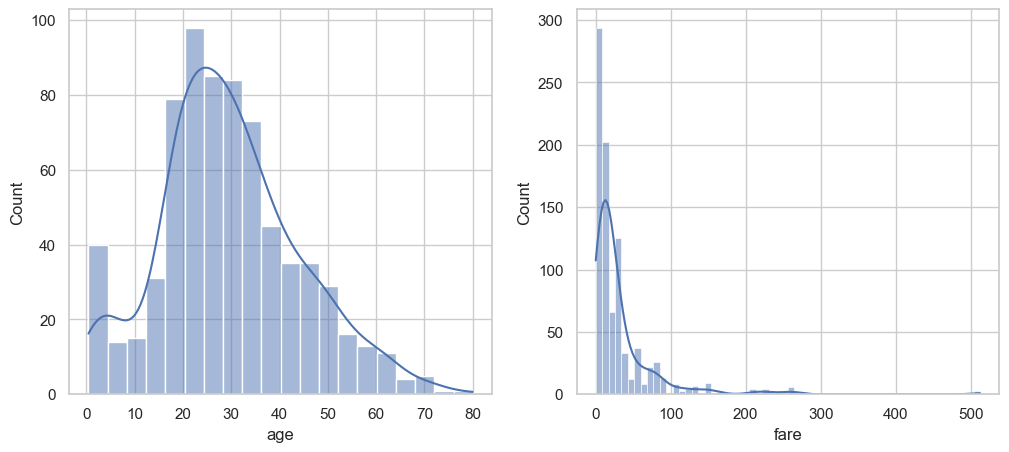

In [21]:
# TODO 5a: Histogram age & fare
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(data= df_handled, x="age", kde= True)
plt.subplot(1,2,2)
sns.histplot(data= df_handled, x="fare", kde= True)
plt.show()

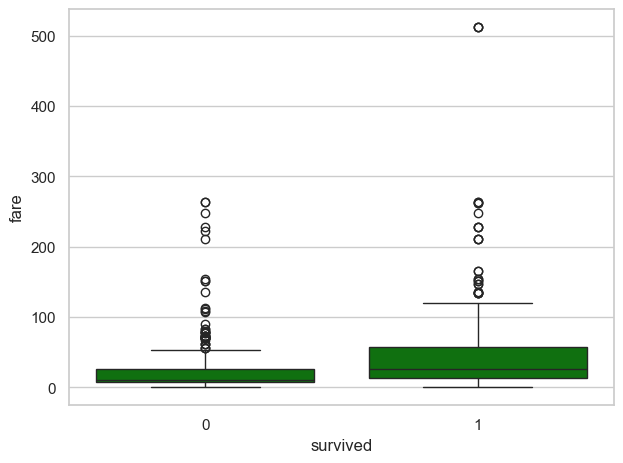

In [22]:
# TODO 5b: Boxplot fare theo survived hoặc pclass
sns.boxplot( x="survived",y="fare", color="green",data=df_handled)
plt.tight_layout()
plt.show()

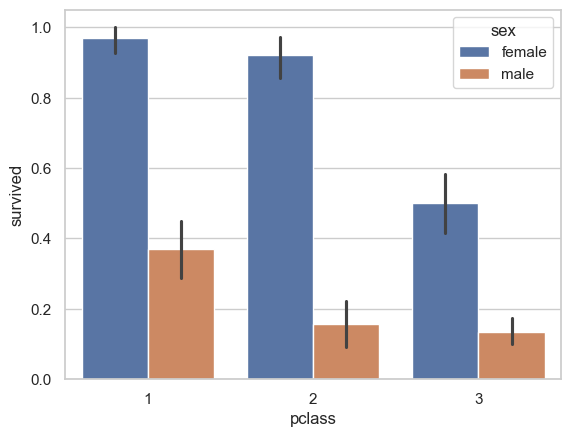

In [23]:
# TODO 5c: Barplot tỷ lệ sống sót theo sex và pclass
sns.barplot(x="pclass", y="survived", hue="sex", data= df_handled)
plt.show()

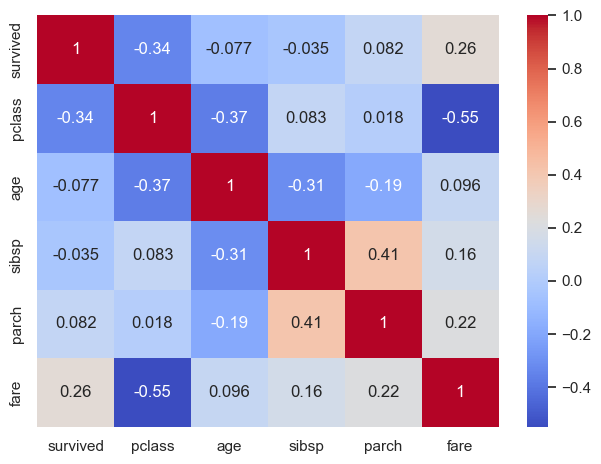

In [24]:
# TODO 5d: Heatmap correlation
sns.heatmap(df_handled.select_dtypes("number").corr(), annot=True, cmap="coolwarm")
plt.tight_layout()
plt.show()


**Nhận xét 5 (viết cho từng biểu đồ ở trên):**

- Histogram: Biểu đồ histogram của age có phần gần với phân phối chuẩn có phần lệch phải nhẹ. Về fare có phân phối khác phân phối chuẩn và lệch phải và đuôi dài chúng tỏ có nhiều ouliner.
- Boxplot: Nhóm sống sót có median cao hơn hẳn so với nhóm còn lại, cho thấy người có vé giá cao hơn có cơ hội sống cao hơn. Cả hai nhóm đều có rất nhiều outliner.
- Bar survival: Tỉ lệ nữ sống sót cao hơn hẳn nam ở cả 3 hạng vé, độ lệch lần lượt là 60%, 75%, 40%. Tỉ lệ sống sót có sự giảm dần theo các hạng vé.
- Heatmap: Cặp pclass và fare có sự tương quan âm lớn nhất vì vé hạng nhất sẽ có giá càng đắt.

---
## Task 6 — Chia tập **TRƯỚC** khi tiền xử lý (chống data leakage)

### Mục đích
Đây là điểm mấu chốt của buổi học. Mọi phép "học tham số" từ dữ liệu (median để điền, min/max/IQR để scale, danh mục để encode) **chỉ được học từ tập train**. Nếu học từ toàn bộ dữ liệu rồi mới chia, thông tin của tập test đã **rò rỉ** — điểm đánh giá sẽ ảo.

⇒ **Vì vậy phải chia tập TRƯỚC**, rồi mới xử lý.

### Yêu cầu
1. Tách `X` (đặc trưng) và `y` (`survived`).
2. Chia **train / validation / test** theo tỷ lệ khoảng **70 / 15 / 15**, có **`stratify=y`** để giữ nguyên tỷ lệ hai lớp.
3. In shape của 3 tập và **tỷ lệ sống sót** trong mỗi tập (để kiểm tra stratify hoạt động).

### Gợi ý
- Dùng `train_test_split` **hai lần**: lần 1 tách test (15%), lần 2 tách val từ phần còn lại.
- `stratify` nhận vào nhãn tương ứng ở mỗi lần chia.

In [25]:
# TODO 6: chia train/val/test có stratify
X = df_handled.drop(columns="survived")
y = df_handled["survived"]
X_tmp, X_test, y_tmp, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_tmp, y_tmp, test_size=0.15, random_state=42, stratify=y_tmp)
print("Train:", X_train.shape, "| Val:", X_val.shape, "| Test:", X_test.shape)
# in tỷ lệ survived từng tập
print("Tỷ lệ survived trong Train:", y_train.mean())
print("Tỷ lệ survived trong Val:", y_val.mean())
print("Tỷ lệ survived trong Test:", y_test.mean())

Train: (643, 7) | Val: (114, 7) | Test: (134, 7)
Tỷ lệ survived trong Train: 0.38413685847589424
Tỷ lệ survived trong Val: 0.38596491228070173
Tỷ lệ survived trong Test: 0.3805970149253731


---
## Task 7 — Xây pipeline tiền xử lý, **fit chỉ trên train**

### Mục đích
Gộp toàn bộ bước tiền xử lý vào một `ColumnTransformer` + `Pipeline`, `fit` **một lần trên `X_train`** rồi `transform` cho val/test. Đây là cách chuẩn để **đảm bảo không leakage** và tái sử dụng được.

### Yêu cầu
Xây `preprocess` gồm:

- **Biến số** (`age`, `sibsp`, `parch`, `fare`): `SimpleImputer(median)` → scaler (chọn `RobustScaler` vì `fare` có outlier, hoặc giải thích lựa chọn khác).
- **Biến phân loại** (`sex`, `embarked`): `SimpleImputer(most_frequent)` → `OneHotEncoder`.
- **Biến thứ tự** (`pclass`): giữ nguyên (`passthrough`) vì đã là số có thứ tự 1 < 2 < 3.

Sau đó: `fit` trên `X_train`, `transform` cho cả ba tập; in shape kết quả và tên cột sau biến đổi.

### Yêu cầu trả lời
- **Trả lời:** giải thích vì sao `fit` chỉ trên train (không phải trên toàn bộ dữ liệu) thì tránh được leakage.

### Gợi ý
- Khung `ColumnTransformer([... ("num", pipe_so, num_cols), ("cat", pipe_cat, cat_cols), ("ord", "passthrough", ord_cols)])`.
- `preprocess.get_feature_names_out()` để xem tên cột sau biến đổi.

In [26]:
num_cols = ["age", "sibsp", "parch", "fare"]
cat_cols = ["sex", "embarked"]
ord_cols = ["pclass"]
# TODO 7: xây pipeline cho biến số và biến phân loại
pipe_so  = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler()),
])
pipe_cat = Pipeline([
    ("imputer", SimpleImputer(strategy= "most_frequent")),
    ("encoder",   OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("num", pipe_so,  num_cols),
    ("cat", pipe_cat, cat_cols),
    ("ord", "passthrough", ord_cols),
])

# preprocess.fit(X_train)               # fit CHỈ trên train
# X_train_t = preprocess.transform(X_train)
# ... transform cho val, test
# print(X_train_t.shape, list(preprocess.get_feature_names_out()))preprocess.fit(X_train)                       # fit CHỈ trên train

preprocess.fit(X_train)
Xtr = preprocess.transform(X_train)
Xva = preprocess.transform(X_val)
Xte = preprocess.transform(X_test)
print("Sau tiền xử lý — train:", Xtr.shape, "| val:", Xva.shape, "| test:", Xte.shape)
print("Tên cột sau biến đổi:", list(preprocess.get_feature_names_out()))

Sau tiền xử lý — train: (643, 8) | val: (114, 8) | test: (134, 8)
Tên cột sau biến đổi: ['num__age', 'num__sibsp', 'num__parch', 'num__fare', 'cat__sex_male', 'cat__embarked_Q', 'cat__embarked_S', 'ord__pclass']


**Trả lời 7 (vì sao fit chỉ trên train tránh leakage):**

*(viết tại đây...)*
Chỉ fit trên tập train để các tham số tiền xử lý (như median, mean, IQR,...) được học từ dữ liệu huấn luyện. Sau đó chỉ dùng transform cho tập validation và test. Điều này giúp tránh data leakage, vì mô hình không sử dụng bất kỳ thông tin nào từ dữ liệu validation hoặc test trong quá trình huấn luyện và tiền xử lý.

---
## Task 8 — Câu hỏi tư duy: chọn metric đánh giá

### Mục đích
Buổi học nhấn mạnh: **không có metric tốt nhất tuyệt đối** — phải chọn theo bài toán và mức mất cân bằng dữ liệu. Bài này không cần code, chỉ cần lập luận.

### Yêu cầu — trả lời ngắn gọn:
1. Biến mục tiêu `survived` có **mất cân bằng** không? (tính tỷ lệ hai lớp để trả lời).
2. Nếu chỉ nhìn **Accuracy**, có thể bị đánh lừa trong trường hợp nào?
3. Với bài toán Titanic, bạn sẽ ưu tiên metric nào (Accuracy / Precision / Recall / F1)? Vì sao?

In [27]:
# TODO 8: tính tỷ lệ hai lớp của 'survived' để hỗ trợ trả lời
ty_le_song_sot = df['survived'].mean() * 100
print(f"Tỷ lệ sống sót (lớp 1): {ty_le_song_sot:.2f}%")
print(f"Tỷ lệ thiệt mạng (lớp 0): {100 - ty_le_song_sot:.2f}%")

Tỷ lệ sống sót (lớp 1): 38.38%
Tỷ lệ thiệt mạng (lớp 0): 61.62%


**Trả lời 8:**

1. Biến mục tiêu survided có mất cân bằng giữa lớp 1 (38.38%) và lớp 0 (61.62%)
2. Do Accuracy đo tỉ lệ đoán đúng trên tổng số mẫu nên khi tập dữ liệu bị mất cân bằng hoàn toàn về 1 bên như (95% và 5%) thì mô hình sẽ xảy ra hiện tượng đoán bừa.
3. Với bài toán Titanic, bạn sẽ ưu tiên metric Accuracy, vì tỷ lệ mất cân bằng của bài toán Titanic là rất nhẹ (khoảng 60:40), chưa đủ để làm sai lệch chỉ số. Đồng thời, hậu quả của việc đoán sai giữa lớp 0 và lớp 1 trong bài toán này không có sự chênh lệch mang tính sống còn (như y tế).

---
## Task 9 — Nhận xét tổng hợp về dữ liệu

### Mục đích
Khép lại toàn bộ EDA bằng một bản tóm tắt như một data analyst gửi cho đồng đội: **những gì đáng chú ý nhất** về bộ dữ liệu này.

### Yêu cầu — viết ít nhất 5 gạch đầu dòng, dựa trên **bằng chứng** (số liệu / biểu đồ) ở trên:
- Đặc trưng nào **tương quan mạnh nhất** với khả năng sống sót? (số liệu chứng minh)
- Cột nào **thiếu nhiều nhất** và bạn đã xử lý thế nào?
- Biến mục tiêu có **mất cân bằng** không? ảnh hưởng gì tới việc chọn metric?
- Đặc trưng nào cần **scaling**, đặc trưng nào cần **encoding**? vì sao?
- Một điều bạn thấy **bất ngờ / thú vị** trong dữ liệu.

**Nhận xét tổng hợp của bạn:**

1. Đặc trưng pclass có tương quan âm lớn nhất so với khả năng sống sót (-0.34), chứng tỏ hành khách có hạng vé càng cao thì có khả năng sống sót lớn hơn.
2. Cột age thiếu nhiều nhất và em đã xử lý bằng cách điền median vì biến này có nhiều outlier có ý nghĩa.
3. Biến mục tiểu survided có mất cân bằng nhẹ (60 - 40). Việc này có ảnh hưởng nhẹ đến mô hình nếu dùng metric accuracy.
4. Các đặc trưng là dữ liệu số liên tục hoặc rời rạc (Numerical Features) có độ lớn và đơn vị khác nhau thì ta cần scaling vì khi không có cùng 1 đơn vị thì mô hình sẽ cho rằng các biến có giá trị lớn mới quan trongnj mà bỏ qua các biến có giá trị nhỏ, với các biến phân loại dạng chữ ta cần encoding vì máy chỉ hiểu được số mà không hiểu được chữ.
5. Một điều bất ngờ em thấy được là giá trị của hạng vé vượt trên cả quy tắc nhường nhịn. Ta có thể thấy những hàng khách nam ở khoang hạng nhất có tỉ lệ sống sót không quá chênh lệch với những hành khác nữ ở khoang hạng ba.

---
## (Bonus — không bắt buộc) Thử thách nâng cao

Chọn **một** trong các hướng sau nếu bạn muốn thử sức:

1. **Feature engineering:** tạo đặc trưng mới `family_size = sibsp + parch + 1`, hoặc trích `title` (Mr/Mrs/Miss...) từ tên (nếu dùng bản có cột `name`). Kiểm tra tương quan với `survived`.
2. **So sánh scaler:** vẽ phân phối `fare` trước và sau khi áp `StandardScaler`, `MinMaxScaler`, `RobustScaler`. Nhận xét scaler nào phù hợp nhất với dữ liệu lệch + có outlier.
3. **Bẫy KNN:** thử `KNNImputer` để điền `age` **khi chưa scale** và **sau khi đã scale** `fare`. Quan sát kết quả có khác nhau không, và giải thích tại sao (gợi ý: khoảng cách Euclid bị chi phối bởi cột thang đo lớn).

In [28]:
# (tùy chọn) code cho phần Bonus
...

Ellipsis

---
## Bảng tự kiểm trước khi nộp

- [ ] Notebook chạy **Restart & Run All** không lỗi.
- [ ] Đã bỏ các cột rò rỉ/dư thừa (Task 1) và giải thích được vì sao.
- [ ] Mỗi biểu đồ (Task 5) đều có **nhận xét**.
- [ ] Đã **chia tập trước**, tiền xử lý **fit chỉ trên train** (Task 6–7).
- [ ] Đã trả lời tất cả các phần *"Trả lời:"*.
- [ ] Nhận xét tổng hợp (Task 9) có **ít nhất 5 ý** dựa trên bằng chứng.
- [ ] Đã push lên **repo cá nhân trên GitHub**.
